# Sales Data Analysis



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
df = pd.read_csv('train.csv')
print('Dataset loaded!')
print('Rows:', df.shape[0], ' | Columns:', df.shape[1])


Dataset loaded!
Rows: 9800  | Columns: 18


## 3. Basic Data Exploration

### First 5 rows

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Dataset shape and column names

In [4]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())


Shape: (9800, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


### Data types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

### Statistical summary

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Missing values

In [7]:
print('Missing values per column:')
print(df.isnull().sum())


Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


## 4. Simple Data Cleaning

In [8]:
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Month'] = df['Order Date'].dt.month
df['Year']  = df['Order Date'].dt.year

print('Cleaning done!')
print('Order Date type:', df['Order Date'].dtype)


Cleaning done!
Order Date type: datetime64[us]


## 5. Data Analysis

### Total and Average Sales

In [9]:
sales = df['Sales'].values   # NumPy array

print('Total Sales   : $', round(np.sum(sales), 2))
print('Average Sale  : $', round(np.mean(sales), 2))
print('Median Sale   : $', round(np.median(sales), 2))
print('Std Deviation : $', round(np.std(sales), 2))
print('Min Sale      : $', round(np.min(sales), 2))
print('Max Sale      : $', round(np.max(sales), 2))


Total Sales   : $ 2261536.78
Average Sale  : $ 230.77
Median Sale   : $ 54.49
Std Deviation : $ 626.62
Min Sale      : $ 0.44
Max Sale      : $ 22638.48


### Sales by Category

In [10]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


### Sales by Region

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)


Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


### Top 10 Products by Sales

In [12]:
top10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top10_products)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


### Monthly Sales

In [13]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales = df.groupby('Month')['Sales'].sum()

for m, val in monthly_sales.items():
    print(f'{month_names[m-1]:>3}  ${val:,.2f}')


Jan  $94,291.63
Feb  $59,371.12
Mar  $197,573.59
Apr  $136,283.00
May  $154,086.72
Jun  $145,837.52
Jul  $145,535.69
Aug  $157,315.93
Sep  $300,103.41
Oct  $199,496.29
Nov  $350,161.71
Dec  $321,480.17


## 6. Visualizations

### Chart 1: Sales by Category

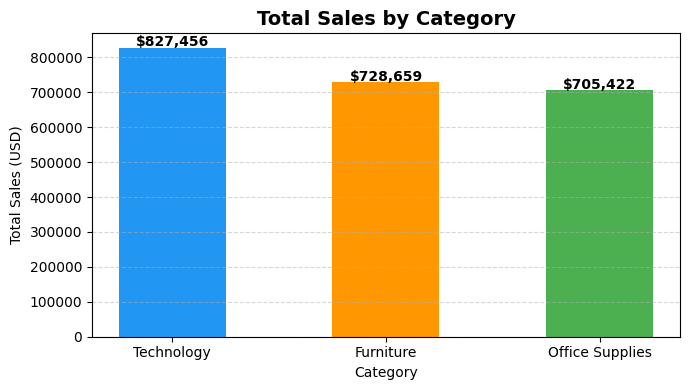

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(category_sales.index, category_sales.values,
       color=['#2196F3', '#FF9800', '#4CAF50'], width=0.5)

ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales (USD)')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for i, val in enumerate(category_sales.values):
    ax.text(i, val + 5000, f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_category.png', dpi=100, bbox_inches='tight')
plt.show()


### Chart 2: Sales by Region

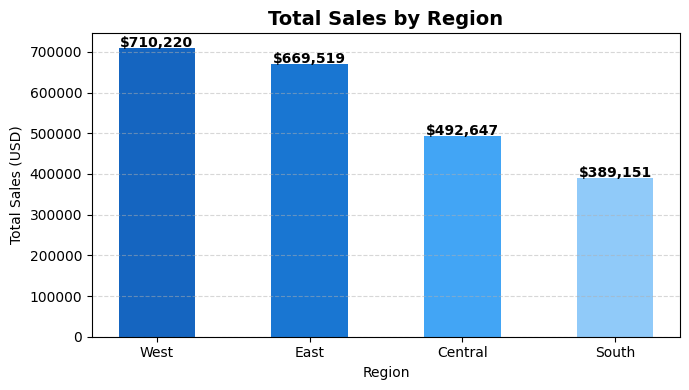

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(region_sales.index, region_sales.values,
       color=['#1565C0', '#1976D2', '#42A5F5', '#90CAF9'], width=0.5)

ax.set_title('Total Sales by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales (USD)')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for i, val in enumerate(region_sales.values):
    ax.text(i, val + 3000, f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_region.png', dpi=100, bbox_inches='tight')
plt.show()


### Chart 3: Top 10 Products by Sales

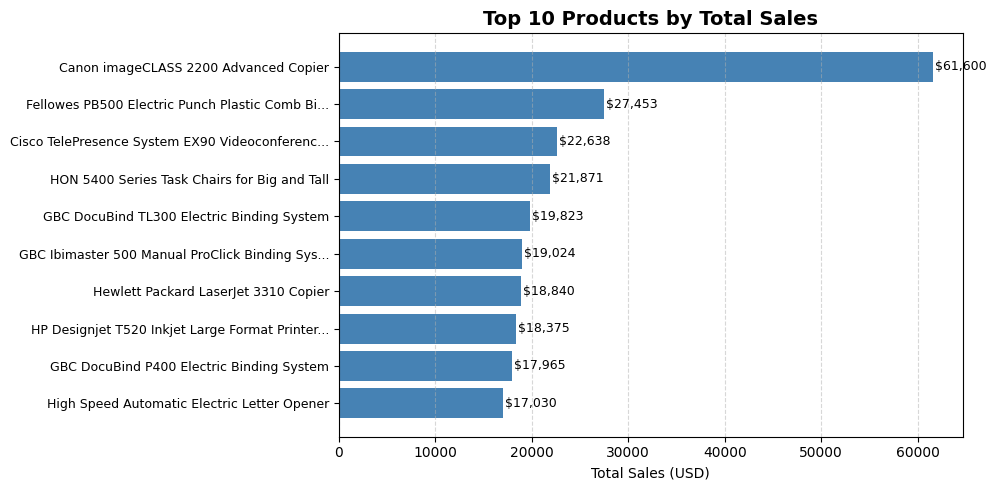

In [16]:
short_names = [name[:45] + '...' if len(name) > 45 else name
               for name in top10_products.index]

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(range(len(top10_products)), top10_products.values, color='steelblue')

ax.set_yticks(range(len(top10_products)))
ax.set_yticklabels(short_names, fontsize=9)
ax.set_title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (USD)')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.invert_yaxis()

for bar, val in zip(ax.patches, top10_products.values):
    ax.text(val + 200, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart3_products.png', dpi=100, bbox_inches='tight')
plt.show()


### Chart 4: Monthly Sales Trend

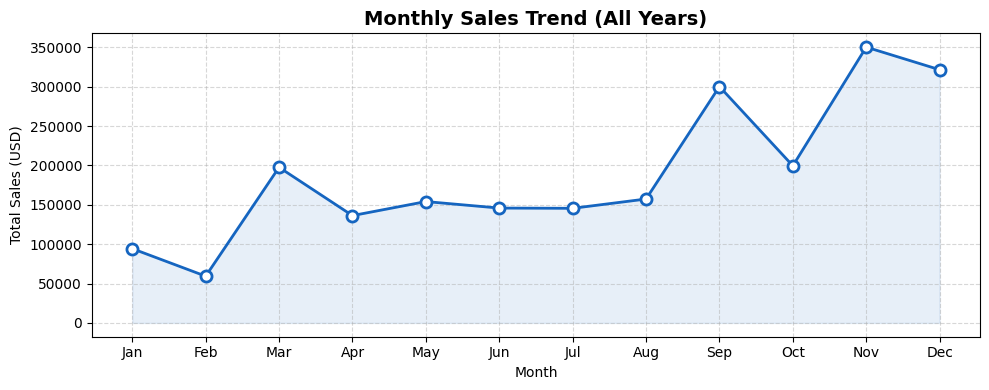

In [17]:
months = list(range(1, 13))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Month')['Sales'].sum().reindex(months)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(months, monthly.values, marker='o', linewidth=2,
        color='#1565C0', markerfacecolor='white', markeredgewidth=2, markersize=8)
ax.fill_between(months, monthly.values, alpha=0.1, color='#1565C0')

ax.set_title('Monthly Sales Trend (All Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (USD)')
ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart4_monthly.png', dpi=100, bbox_inches='tight')
plt.show()


### Chart 5: Sales Distribution (Histogram)

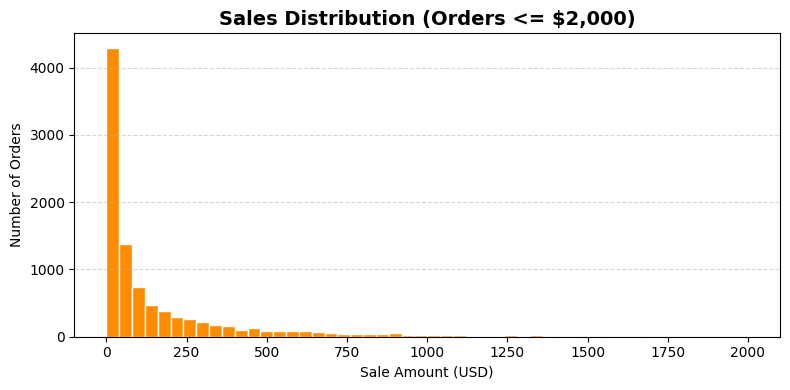

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df[df['Sales'] <= 2000]['Sales'], bins=50,
        color='darkorange', edgecolor='white')

ax.set_title('Sales Distribution (Orders <= $2,000)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sale Amount (USD)')
ax.set_ylabel('Number of Orders')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart5_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Insights

In [19]:
top_category   = category_sales.index[0]
top_region     = region_sales.index[0]
weak_region    = region_sales.index[-1]
top_product    = top10_products.index[0]
best_month_num = monthly_sales.idxmax()
best_month     = month_names[best_month_num - 1]
worst_month    = month_names[monthly_sales.idxmin() - 1]
median_sale    = np.median(df['Sales'].values)
mean_sale      = np.mean(df['Sales'].values)

print('--- BUSINESS INSIGHTS ---')
print()
print('1. Top Category :', top_category,
      'generates the highest total revenue.')
print()
print('2. Best Region  :', top_region,
      'leads in sales. The', weak_region, 'region is the weakest.')
print()
print('3. Top Product  :', top_product[:60])
print('   is the highest-selling individual product.')
print()
print('4. Peak Month   :', best_month,
      'records the highest monthly sales (Q4 holiday effect).')
print()
print('5. Slowest Month:', worst_month,
      'is the weakest month — good window for promotions.')
print()
print('6. Skewed Orders: Median sale ($' + str(round(median_sale, 2)) +
      ') << Mean ($' + str(round(mean_sale, 2)) +
      '). Most orders are small; a few large orders pull the average up.')
print()
print('7. Sales Trend  : Sales grew year-over-year from 2014 to 2017,'
      ' showing consistent business growth.')


--- BUSINESS INSIGHTS ---

1. Top Category : Technology generates the highest total revenue.

2. Best Region  : West leads in sales. The South region is the weakest.

3. Top Product  : Canon imageCLASS 2200 Advanced Copier
   is the highest-selling individual product.

4. Peak Month   : Nov records the highest monthly sales (Q4 holiday effect).

5. Slowest Month: Feb is the weakest month — good window for promotions.

6. Skewed Orders: Median sale ($54.49) << Mean ($230.77). Most orders are small; a few large orders pull the average up.

7. Sales Trend  : Sales grew year-over-year from 2014 to 2017, showing consistent business growth.
